## 11. First results from stacking filaments

The following notebook works on developing the code for stacking of filament images with the eRASS:4 survey! :D The aim of the class must be as follows:
1. Mask clusters and point sources in the field of view
5. Create appropriate bins to stack objects (at least in redshift and length)
6. Create masks to straighten the filaments
7. Squeeze the filaments based on their endpoints


**Author**: Soumya Shreeram <br/>
**Contact email**: shreeram@mpe.mpg.de <br/>
**Date created**: 26th October 2022 <br/>
**Date last editted**: tbd

In [1]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits
from astropy.table import Table, Column, QTable
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18, z_at_value
from astropy import wcs

import numpy as np
import pandas as pd

# system imports
import os
import sys
import importlib as ib
import glob
import copy

from scipy import interpolate
# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Arc
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.colors import LogNorm, Normalize
import seaborn as sns

from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd, find_optimal_celestial_wcs

In [2]:
import filaments as fo

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 18}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [7]:
straighten_filament = fo.StraightenFilaments(data_set='lc_north_dis',
                                           smoothing_density_f='SD2',
                                           persistence=5,
                                           smoothing_skeleton='S001',
                                           fil_id = 96)

INFO:StraightenFilaments:<DisPerSEcatalog2eRass(data_set=lc_north_dis, smoothing_density_f=SD2, persistence=5, smoothing_skeleton=S001, section=fil)>
INFO:StraightenFilaments:total filaments available 351
INFO:StraightenFilaments:===========

INFO:StraightenFilaments:German half of the sky has:
INFO:StraightenFilaments:Total 220
INFO:StraightenFilaments:Length and orientation cut 11
INFO:StraightenFilaments:Only length cut 18
INFO:StraightenFilaments:Only orientation cut 134
INFO:StraightenFilaments:===========

INFO:StraightenFilaments:Russian half of the sky has:
INFO:StraightenFilaments:Total 131
INFO:StraightenFilaments:Length and orientation cut 21
INFO:StraightenFilaments:Only length cut 28
INFO:StraightenFilaments:Only orientation cut 101
INFO:StraightenFilaments:===========

INFO:StraightenFilaments:fil_id=96
INFO:StraightenFilaments:'proc_v_folder' default set to c020
INFO:StraightenFilaments:'pattern' not set; setting it to the default value of '15'
INFO:StraightenFilaments:'

### Putting together the filament sub-images into a single filament image

In [8]:
whole_fil_array, whole_fil_footprint, wcs_out, _ = straighten_filament.get_mosiac_image()

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
Set MJD-OBS to 58868.263935 from DATE-OBS.
Set MJD-END to 59426.048565 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58868.263935 from DATE-OBS.
Set MJD-END to 59426.048565 from DATE-END'.
Set MJD-OBS to 58868.097315 from DATE-OBS.
Set MJD-END to 59425.882060 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58868.097315 from DATE-OBS.
Set MJD-END to 59425.882060 from DATE-END'.
Set MJD-OBS to 58867.763843 from DATE-OBS.
Set MJD-END to 59425.548762 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58867.763843 from DATE-OBS.
Set MJD-END to 59425.548762 from DATE-END'.
Set MJD-OBS to 58865.764097 from DATE-OBS.
Set MJD-END to 59424.214931 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58865.764097 from DATE-OBS.
Set MJD-END to 59424.214931 from DATE-END'.
Set MJD-OBS to 58865.764352 from DATE-OBS.
Set MJD-END to 59424.215174 from DATE-END'. [astropy.wcs.wcs]
Set MJD-O

INFO:StraightenFilaments:vmin=0.0, vmax=120.26074212995539


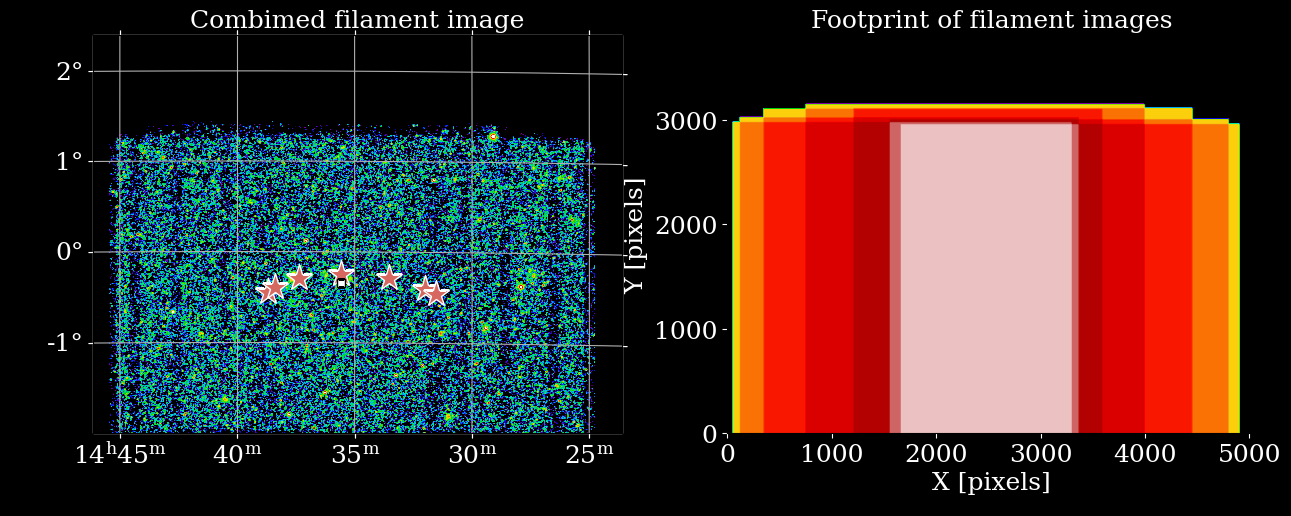

In [9]:
ax1, ax2 = straighten_filament.plot_whole_filament(wcs_out, 
                                                   whole_fil_array, 
                                                   whole_fil_footprint, 
                                                   rotate=False)

In [ ]:
out = straighten_filament.get_mosiac_image(rotate=True)
whole_fil_rot_array, whole_fil_rot_footprint, wcs_out, wcs_rot_out = out

INFO:StraightenFilaments:vmin=0.0, vmax=9.017772296583118


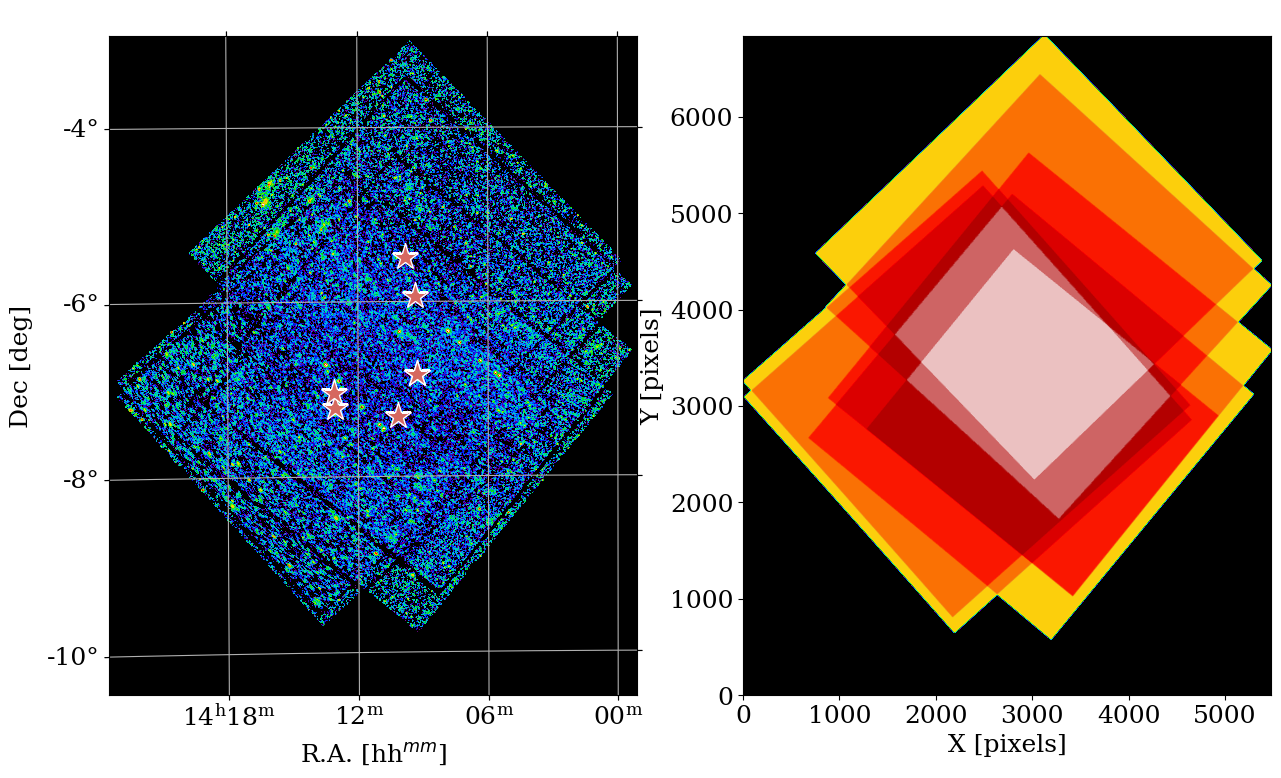

In [22]:
ax1, ax2 = straighten_filament.plot_whole_filament(wcs_out, 
                                                   whole_fil_rot_array, 
                                                   whole_fil_rot_footprint,
                                                  wcs_rot_out=wcs_rot_out)

### The last step is to get a cut out of each filament sub-image

In [10]:
from astropy.nddata import Cutout2D

In [11]:
print(f"{straighten_filament.directory_name}")
print(f"{straighten_filament.filament_name}")
print(f"{straighten_filament.data_location}")
print(f"crop_size = {straighten_filament.crop_size_Mpc} Mpc")
print(f"crop_size = {straighten_filament.rcrop:.2f} deg")

lc_north_dis_SD2_s5.0_S001
filid96_len_71.41Mpc_7seg_2.47deg_z0.544
/he13srv_local/shreeram/eRass_products
crop_size = 40 Mpc
crop_size = 1.69 deg


### But first, we need to check the rotation of an individual filament sub-image

In [12]:
straighted_fil, new_x_ends, new_y_ends = straighten_filament.append_straightened_cutouts()

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
Set MJD-OBS to 58868.263935 from DATE-OBS.
Set MJD-END to 59426.048565 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58868.263935 from DATE-OBS.
Set MJD-END to 59426.048565 from DATE-END'.
Set MJD-OBS to 58868.097315 from DATE-OBS.
Set MJD-END to 59425.882060 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58868.097315 from DATE-OBS.
Set MJD-END to 59425.882060 from DATE-END'.
Set MJD-OBS to 58867.763843 from DATE-OBS.
Set MJD-END to 59425.548762 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58867.763843 from DATE-OBS.
Set MJD-END to 59425.548762 from DATE-END'.
Set MJD-OBS to 58865.764097 from DATE-OBS.
Set MJD-END to 59424.214931 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58865.764097 from DATE-OBS.
Set MJD-END to 59424.214931 from DATE-END'.
Set MJD-OBS to 58865.764352 from DATE-OBS.
Set MJD-END to 59424.215174 from DATE-END'. [astropy.wcs.wcs]
Set MJD-O

UnboundLocalError: local variable 'i' referenced before assignment

In [74]:
fil_id_arr = straighten_filament.get_selected_filament_ids()
len(fil_id_arr)

INFO:StraightenFilaments:masked entries=80


22

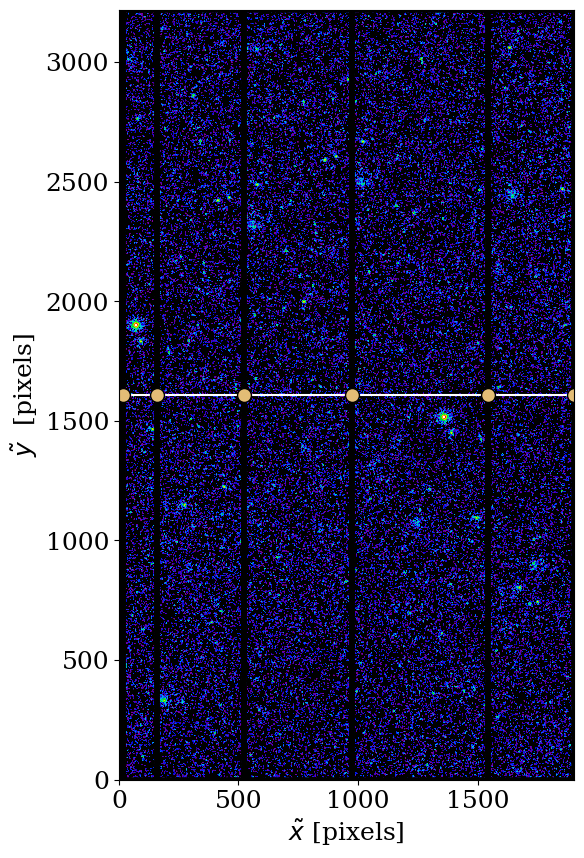

In [72]:
from astropy.visualization import simple_norm

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#fig.set_facecolor('black')
norm1 = simple_norm(straighted_fil.T, 'log', min_cut=1e-2, max_cut=10) 
ax.plot(new_x_ends, new_y_ends, 'w-o', mfc='#e3bd76', ms=10, mec='k')
for i in range(len(new_x_ends)-1):
    x = new_x_ends[i]
    width = new_x_ends[i+1]-new_x_ends[i]
    height = straighted_fil.T.shape[0]
    rect = patches.Rectangle((x, 0), width, height, ls='-', ec='k', fc='None', lw=4)
    ax.add_patch(rect)
ax.imshow(straighted_fil.T, origin='lower', cmap=fo.custom_colormap(), norm=norm1)
fo.set_labels(ax, r"$\tilde{x}$ [pixels]", r"$\tilde{y}$  [pixels]")
#fo.set_as_white(ax)

In [82]:
def rebin(a, new_shape):
    M, N = a.shape
    m, n = new_shape
    if m<M:
        return a.reshape((m,M//m,n,N//n)).mean(3).mean(1)
    else:
        return np.repeat(np.repeat(a, m//M, axis=0), n//N, axis=1)

In [83]:
new_fil_rebinned = rebin(straighted_fil, (100, 50))


ValueError: cannot reshape array of size 6130880 into shape (100,19,50,64)

### Proof of concept for straightening of filaments

In [ ]:
fig = plt.figure(figsize=(5, 5))
ax = plt.subplot(1,1,1, projection=wcs_out)
ax = plt.subplot(1, 1, 1)

ra_fil, dec_fil = [coord[i][0] for i in range(len(coord))], [coord[i][1] for i in range(len(coord))]
ax.plot(ra_fil, dec_fil, c='grey', ls='-', alpha=0.4)
for i in range(len(coord)):
    ax.plot(coord[i][0], coord[i][1], 'rs')
    if i != len(coord) - 1:
        ax.plot(mid_coord[0, i], mid_coord[1, i], 'bs')
    
fo.set_labels(ax, r"R.A. [hh$^{mm}$]", 'Dec [deg]')
f"Filament number ={straighten_filament.fil_id}"

'Filament number =96'

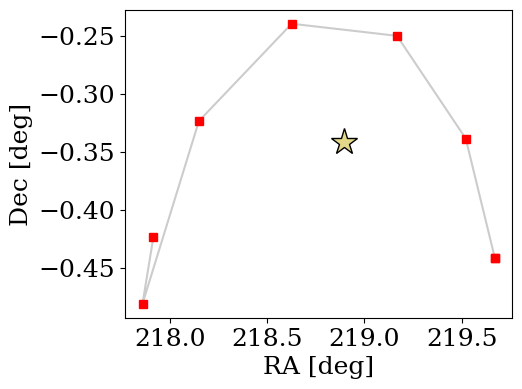

In [21]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
x_test, y_test = [coord[i][0] for i in range(len(coord))], [coord[i][1] for i in range(len(coord))]
ax.plot(x_test, y_test, c='grey', ls='-',alpha=0.4)
for i in range(len(coord)):
    ax.plot(coord[i][0], coord[i][1], 'rs')
    
ax.plot(this_file.median_ra, this_file.median_dec, '*', c='#e3d788', ms=20, mec='k')
fo.set_labels(ax, xlabel='RA [deg]', ylabel='Dec [deg]')
f"Filament number ={this_file.fil_id}"

'Filament number =96'

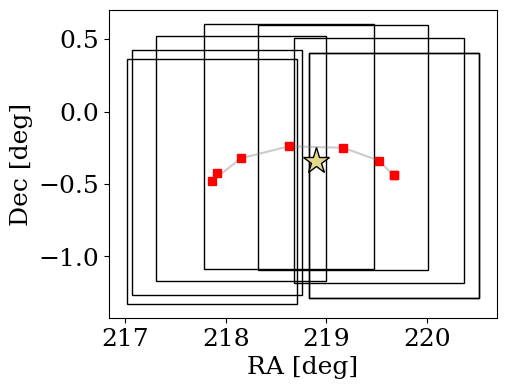

In [22]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
x_test, y_test = [coord[i][0] for i in range(len(coord))], [coord[i][1] for i in range(len(coord))]
ax.plot(x_test, y_test, c='grey', ls='-', alpha=0.4)
for i in range(len(coord)):
    ax.plot(coord[i][0], coord[i][1], 'rs')
    rect = patches.Rectangle((coord[i][0]-this_file.rcrop/2, coord[i][1]-this_file.rcrop/2), this_file.rcrop, this_file.rcrop, linewidth=1, edgecolor='k', facecolor='none')

    # Add the patch to the Axes
    ax.add_patch(rect)
ax.plot(this_file.median_ra, this_file.median_dec, '*', c='#e3d788', ms=20, mec='k')
fo.set_labels(ax, xlabel='RA [deg]', ylabel='Dec [deg]')
f"Filament number ={this_file.fil_id}"

'Filament number =96'

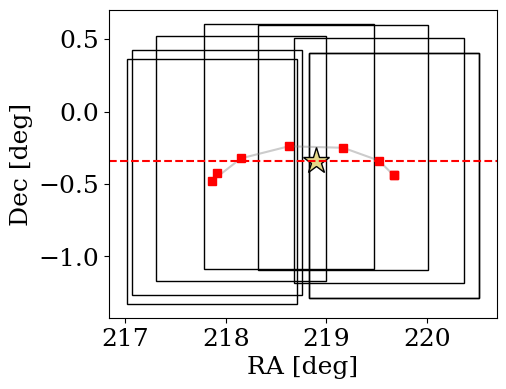

In [23]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
x_test, y_test = [coord[i][0] for i in range(len(coord))], [coord[i][1] for i in range(len(coord))]
ax.plot(x_test, y_test, c='grey', ls='-', alpha=0.4)
for i in range(len(coord)):
    ax.plot(coord[i][0], coord[i][1], 'rs')
    rect = patches.Rectangle((coord[i][0]-this_file.rcrop/2, coord[i][1]-this_file.rcrop/2), this_file.rcrop, this_file.rcrop, linewidth=1, edgecolor='k', facecolor='none')

    # Add the patch to the Axes
    ax.add_patch(rect)
ax.plot(this_file.median_ra, this_file.median_dec, '*', c='#e3d788', ms=20, mec='k')
ax.axhline(this_file.median_dec, ls='--', c='r', zorder=2)
fo.set_labels(ax, xlabel='RA [deg]', ylabel='Dec [deg]')
f"Filament number ={this_file.fil_id}"

Since we don't really care about ra, dec at this point, let's just move to pixel units

In [24]:
def get_offset(this_file, coord):
    straightening_axies = [(coord[i][0], this_file.median_dec) for i in range(len(coord))]
    dist_off_array = np.array([])
    for i in range(len(coord)): 
        x_off, y_off = coord[i]
        x, y = straightening_axies[i]
        dist_off = np.sqrt((x_off-x)**2 + (np.abs(y)- np.abs(y_off) )**2)
        dist_off_array = np.append(dist_off_array, dist_off)
    return dist_off_array, straightening_axies

'Filament number =96'

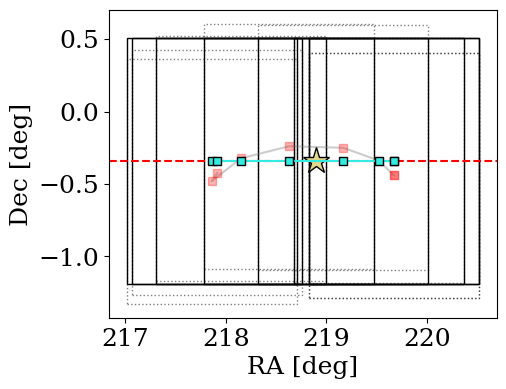

In [25]:
fig, ax = plt.subplots(1,1,figsize=(5,4))
# plots the filament centers
x_test, y_test = [coord[i][0] for i in range(len(coord))], [coord[i][1] for i in range(len(coord))]
ax.plot(x_test, y_test, c='grey', ls='-', alpha=0.4)

# plots the straigthened filament centers
dist_off_array, straightening_axies = get_offset(this_file, coord)
ax.plot(x_test, this_file.median_dec*np.ones(len(x_test)), c='#34ebe1', marker='s', mec='k', 
        zorder=3)
for i in range(len(coord)):
    ax.plot(coord[i][0], coord[i][1], 'rs', alpha=0.3)
    rect = patches.Rectangle((coord[i][0]-this_file.rcrop/2, 
                              coord[i][1]-this_file.rcrop/2), 
                             this_file.rcrop, this_file.rcrop, 
                             linewidth=1, edgecolor='k', facecolor='none', alpha=0.5,
                            linestyle=':')
    
    new_rect = patches.Rectangle((x_test[i]-this_file.rcrop/2, 
                              this_file.median_dec-this_file.rcrop/2), 
                             this_file.rcrop, this_file.rcrop, 
                             linewidth=1, edgecolor='k', facecolor='none')
    # Add the patch to the Axes
    ax.add_patch(rect)
    ax.add_patch(new_rect)
ax.plot(this_file.median_ra, this_file.median_dec, '*', c='#e3d788', ms=20, mec='k')
ax.axhline(this_file.median_dec, ls='--', c='r', zorder=2)
fo.set_labels(ax, xlabel='RA [deg]', ylabel='Dec [deg]')
f"Filament number ={this_file.fil_id}"

### Calculating angle of filaments wrt horizontal axis

In [18]:
from sympy import Point, Segment, Line
import sympy as sp

In [ ]:
def get_perpendicular(fil_segment):
    perpendicular_line = fil_segment.perpendicular_bisector()
    r = perpendicular_line.random_point(seed=42)  # seed value is optional
    point_perpendicular = r.n(3)
    return point_perpendicular, perpendicular_line

def get_rotated_images(wcs_img_arr, x_c, y_c):
    dy = 100
    wcs_rotimg_arr = np.array([])
    for i in range(len(wcs_img_arr)-1):
        point1, point2 = Point(x_c[i], y_c[i]), Point(x_c[i+1], y_c[i+1])
        distance = sp.N(point1.distance(point2))
        print(f"distance={distance}")
        if distance > 1:
            fil_segment = Segment(point1, point2)
            # get the perpendicular point to the filament
            point_perpen_fil, line_perpen_fil = get_perpendicular(fil_segment)

            # gettting the straight filament 
            # ==============================
            median_point, median_point2 = Point(median_x_c, median_y_c), Point(median_x_c, median_y_c+dy)
            straight_fil = Segment(median_point, median_point2)

            # get the perpendicular point to the straightened filament
            point_perpen_str_fil, line_perpen_str_fil = get_perpendicular(straight_fil)

            angle_between_lines = line_perpen_str_fil.smallest_angle_between(line_perpen_fil)
            angle_in_radian = sp.N(angle_between_lines)
            print(f"angle_in_radian={angle_in_radian:.5f}")
            wsc_of_img = wcs_img_arr[i]

            # add rotation to the cutout header
            cdelt1, cdelt2 = wsc_of_img.wcs.cdelt
            wsc_of_img.wcs.pc = define_transformation_matrix_sympy(cdelt1, cdelt2, rot_angle=angle_in_radian)
            wcs_rotimg_arr = np.append(wcs_rotimg_arr, wsc_of_img)  
        else:
            wcs_rotimg_arr = np.append(wcs_rotimg_arr, wcs_img_arr[i])
    wcs_rotimg_arr = np.append(wcs_rotimg_arr, wcs_img_arr[-1])
    return wcs_rotimg_arr

wcs_rotimg_arr = get_rotated_images(wcs_img_arr, x_c, y_c)

Now we see how the filaments look after rotating them

In [22]:
def update_fil_headers(this_file, wcs_rot_arr):
    """Function to get the pixel coordinates of the filament points in the WCS of the pixel
    """
    # get the names and the centers of the concerned image
    images_to_plot = glob.glob(f"{this_file.inputs_folder}/ima_0.2_2.3_*.fits.gz")
    coord = np.loadtxt(f"{this_file.inputs_folder}/image_centers.txt")

    x_c, y_c = np.array([]), np.array([])
    wcs_img_arr = np.array([], dtype=object)
    for i, radec in enumerate(coord):
        hdu_img = fits.open(images_to_plot[i])
        header_img = hdu_img[0].header
        data_img = fits.open(images_to_plot[i])[0].data
        
        # create new Primary Hdu only
        
        # todo: better to change the header entries that rewrite it
        wcs_img = wcs_rot_arr[i]
        header_img['PC1_1'] = 1
        header_img['PC1_2'] = 1
        header_img['PC2_1'] = -1
        header_img['PC2_2'] = 1
        
        hdu_new = fits.PrimaryHDU(data_img,header=header_img)
        #hdulist_new = fits.HDUList([hdu_new])
        hdu_new.writeto(f"{this_file.inputs_folder}/ima_rot_fil{i}.fits.gz",overwrite=True)
        
        ra, dec = radec
        x, y = get_pixel_numbers(wcs_img, ra, dec)
        x_c= np.append(x_c, x)
        y_c= np.append(y_c, y)
    return x_c, y_c
x_c_rotfil, y_c_rotfil = update_fil_headers(this_file, wcs_rotimg_arr)

In [23]:
wcs_rot_out, shape_rot_out = find_optimal_celestial_wcs(images_to_plot)


print(shape_rot_out)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
Set MJD-OBS to 58870.097350 from DATE-OBS.
Set MJD-END to 59424.715220 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58870.097350 from DATE-OBS.
Set MJD-END to 59424.715220 from DATE-END'.
Set MJD-OBS to 58869.930544 from DATE-OBS.
Set MJD-END to 59424.548542 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58869.930544 from DATE-OBS.
Set MJD-END to 59424.548542 from DATE-END'.
Set MJD-OBS to 58867.431053 from DATE-OBS.
Set MJD-END to 59422.881574 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58867.431053 from DATE-OBS.
Set MJD-END to 59422.881574 from DATE-END'.
Set MJD-OBS to 58867.764294 from DATE-OBS.
Set MJD-END to 59423.048461 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58867.764294 from DATE-OBS.
Set MJD-END to 59423.048461 from DATE-END'.
Set MJD-OBS to 58869.264016 from DATE-OBS.
Set MJD-END to 59424.214977 from DATE-END'. [astropy.wcs.wcs]
Set MJD-O

(3843, 5085)


In [ ]:
images_to_plot_rot = glob.glob(f"{this_file.inputs_folder}/ima_rot_fil*.fits.gz")
for asdima in images_to_plot_rot:
    asd = fits.open(asdima)[0].data
    print(np.where(np.isnan(asd)))
plt.imshow(asd, vmin=0, vmax=1)


In [ ]:
hdus = [fits.open(names)[0] for names in images_to_plot_rot]

In [ ]:
whole_fil_rot_array, whole_fil_rot_footprint = reproject_and_coadd(hdus,
                                       wcs_rot_out, shape_out=shape_rot_out,
                                       reproject_function=reproject_interp)

In [ ]:
np.min(whole_fil_rot_footprint), np.max(whole_fil_rot_footprint)

In [ ]:
plt.imshow(whole_fil_rot_footprint, vmax=1, vmin=0)

In [ ]:
whole_fil_rot_array.shape

In [ ]:
coord = np.loadtxt(f"{this_file.inputs_folder}/image_centers.txt")
x_c_rot, y_c_rot = np.array([]),  np.array([]) 
for ra, dec in zip(coord[:, 0], coord[:, 1] ):
    x, y = wcs_rot_out.all_world2pix([[ra, dec]],0)[0][0], wcs_out.all_world2pix([[ra, dec]],0)[0][1]
    x_c_rot, y_c_rot= np.append(x_c_rot, x), np.append(y_c_rot, y)
median_x_c_rot, median_y_c_rot = get_pixel_numbers(wcs_rot_out, this_file.median_ra, this_file.median_dec)

In [ ]:
np.max(whole_fil_rot_array[~np.isnan(whole_fil_rot_array)])

In [ ]:
fig = plt.figure(figsize=(15, 5))
ax1 = plt.subplot(1,2,1, projection=wcs_rot_out)
ax1 = plt.subplot(1, 2, 1)
vmax = np.max(whole_fil_rot_array[~np.isnan(whole_fil_rot_array)])
im1 = ax1.imshow(whole_fil_rot_array, origin='lower', norm=LogNorm(vmin=1e-2, vmax=5), cmap='afmhot')
ax1.plot(x_c_rot, y_c_rot,ls='-', marker='*', color='#35f52f',ms=10, zorder=2, mec='#b0868c')
ax1.plot(median_x_c_rot, median_y_c_rot, 'ws', zorder=3, mec='k')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
fig.colorbar(im1, cax=cbar_ax)
fo.set_labels(ax1, r"R.A. [hh:mm]", 'Dec [deg]', 'Combimed filament image')

ax2 = plt.subplot(1,2,1, projection=wcs_rot_out)
ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(whole_fil_rot_footprint, origin='lower', norm=LogNorm(), cmap='afmhot')
fo.set_labels(ax2, "X [pixels]", 'Y [pixels]', 'Footprint of filament images')

In [1]:
import astropy
astropy.__version__

'5.1'